
Decision Tree Feature Importances:
                                        Feature  Importance
0                    diagnoses.age_at_diagnosis    0.563915
5  pathology_details.residual_tumor_measurement    0.157298
4                          diagnoses.figo_stage    0.149052
2                         diagnoses.tumor_grade    0.050027
1                 diagnoses.method_of_diagnosis    0.043138
3                     treatments.treatment_type    0.036571

Random Forest Feature Importances:
                                        Feature  Importance
0                    diagnoses.age_at_diagnosis    0.572245
5  pathology_details.residual_tumor_measurement    0.135270
4                          diagnoses.figo_stage    0.117177
2                         diagnoses.tumor_grade    0.063089
3                     treatments.treatment_type    0.059614
1                 diagnoses.method_of_diagnosis    0.052604

Gradient Boosting Feature Importances:
                                        Feature 

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:37:19] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Feature Importances:
                                        Feature  Importance
4                          diagnoses.figo_stage    0.261082
5  pathology_details.residual_tumor_measurement    0.233629
1                 diagnoses.method_of_diagnosis    0.139235
2                         diagnoses.tumor_grade    0.129277
0                    diagnoses.age_at_diagnosis    0.123857
3                     treatments.treatment_type    0.112920

SVM Feature Importances:
                                        Feature  Importance
4                          diagnoses.figo_stage    0.634250
0                    diagnoses.age_at_diagnosis    0.588601
5  pathology_details.residual_tumor_measurement    0.345302
2                         diagnoses.tumor_grade    0.217376
1                 diagnoses.method_of_diagnosis    0.117371
3                     treatments.treatment_type    0.003779


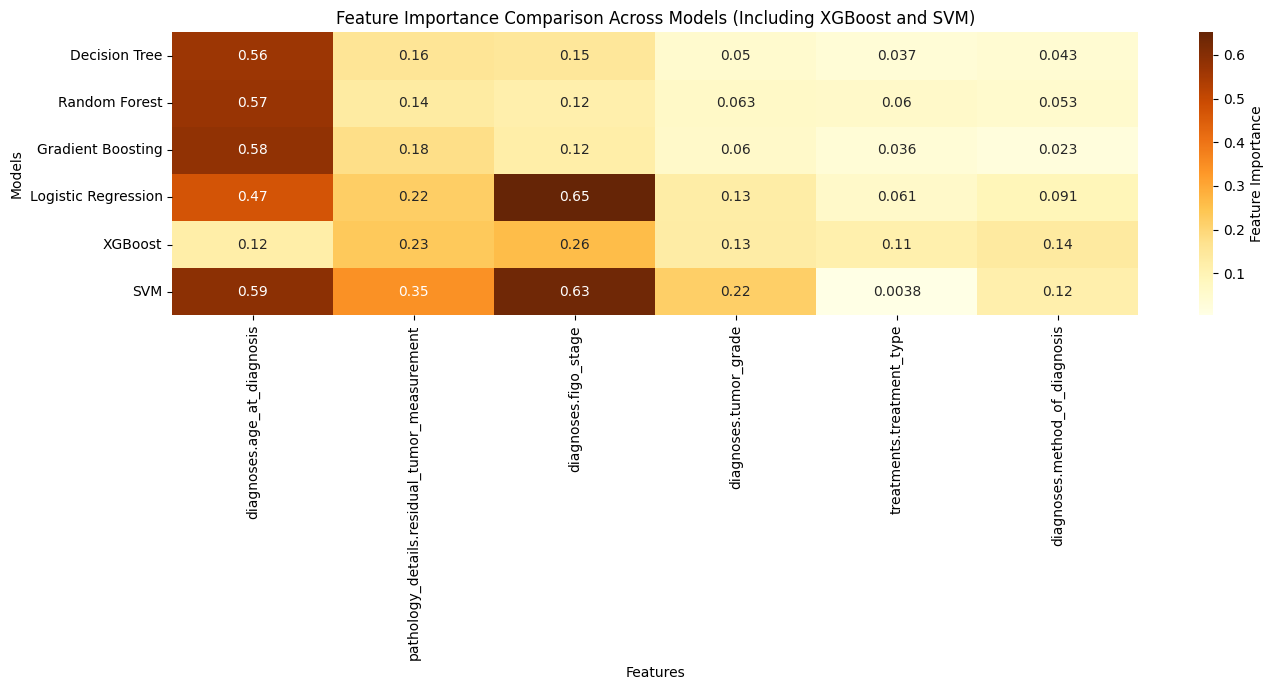

In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("mini data (1).tsv", sep='\t')

# Drop unwanted column and handle missing values
df = df.drop(columns=["demographic.days_to_death"])
df = df.dropna()

# Encode target
df["demographic.vital_status"] = df["demographic.vital_status"].map({"Alive": 0, "Dead": 1})

# Label encode categorical variables
label_encoders = {}
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# Define features and target
X = df.drop(columns=["demographic.vital_status"])
y = df["demographic.vital_status"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
    "SVM": SVC(kernel="linear", probability=True, random_state=42)
}

# Dictionary to store feature importances
importances = {}

# Train and compute importances
for name, model in models.items():
    model.fit(X_train, y_train)
    if hasattr(model, "feature_importances_"):
        imp = model.feature_importances_
    elif hasattr(model, "coef_"):
        imp = abs(model.coef_[0])
    else:
        imp = [0]*X.shape[1]

    importances[name] = imp

    # Show sorted feature importances
    print(f"\n{name} Feature Importances:")
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': imp
    }).sort_values(by='Importance', ascending=False)
    print(feature_importance_df)

# Combine importances into DataFrame
importance_df = pd.DataFrame(importances, index=X.columns)
importance_df = importance_df.sort_values(by="Random Forest", ascending=False)

# Plot heatmap
plt.figure(figsize=(14, 7))
sns.heatmap(importance_df.T, annot=True, cmap="YlOrBr", cbar_kws={"label": "Feature Importance"})
plt.title("Feature Importance Comparison Across Models (Including XGBoost and SVM)")
plt.xlabel("Features")
plt.ylabel("Models")
plt.tight_layout()
plt.show()

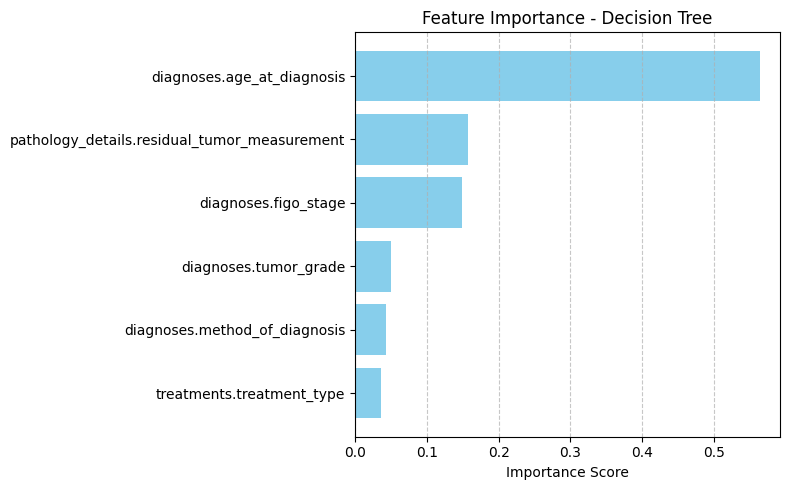

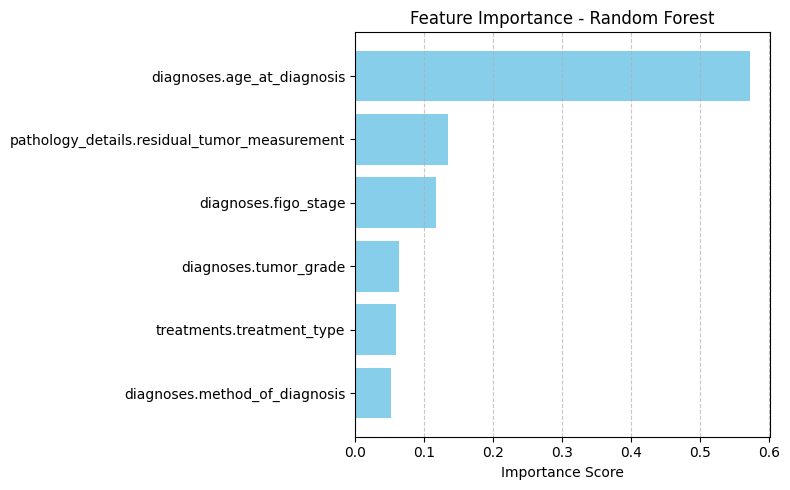

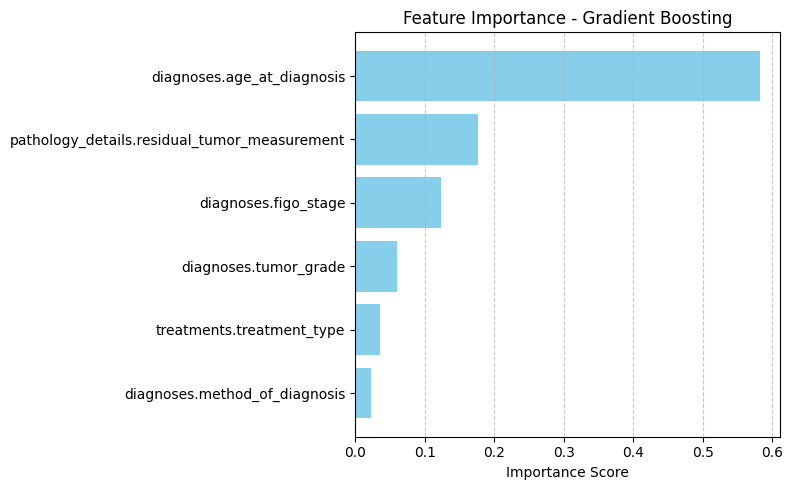

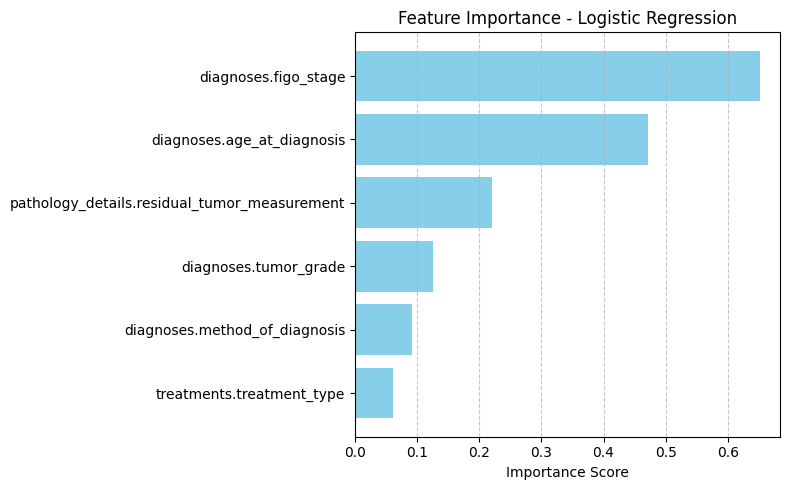

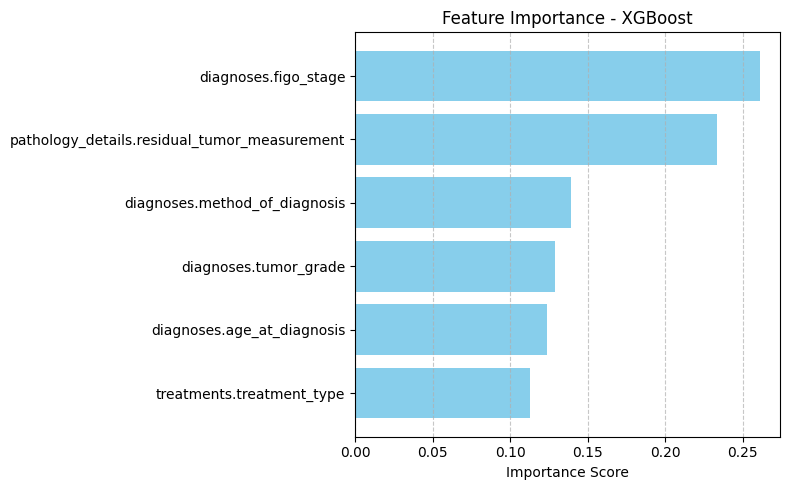

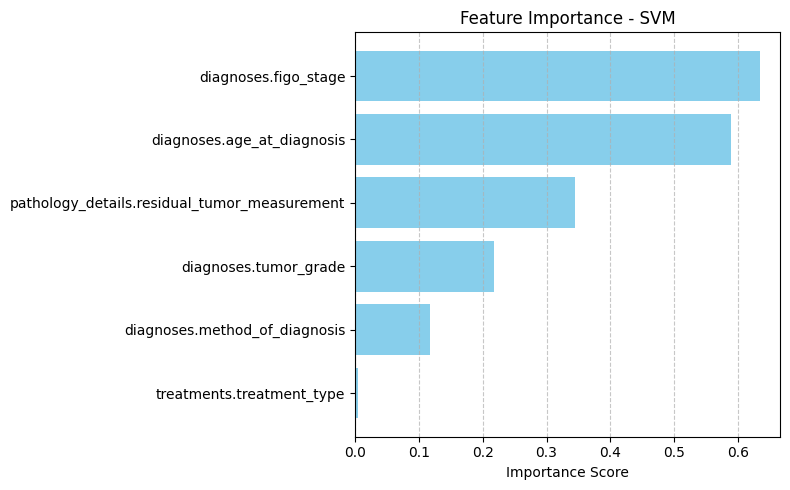

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb

# Load and preprocess data
df = pd.read_csv("mini data (1).tsv", sep='\t')
df = df.drop(columns=["demographic.days_to_death"])
df = df.dropna()
df["demographic.vital_status"] = df["demographic.vital_status"].map({"Alive": 0, "Dead": 1})

label_encoders = {}
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

X = df.drop(columns=["demographic.vital_status"])
y = df["demographic.vital_status"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "XGBoost": xgb.XGBClassifier(eval_metric="logloss", random_state=42),
    "SVM": SVC(kernel="linear", probability=True, random_state=42)
}

importances = {}

# Train and collect importances
for name, model in models.items():
    model.fit(X_train, y_train)
    if hasattr(model, "feature_importances_"):
        imp = model.feature_importances_
    elif hasattr(model, "coef_"):
        imp = abs(model.coef_[0])
    else:
        imp = [0]*X.shape[1]

    importances[name] = imp

    # Plotting horizontal bar chart
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': imp
    }).sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(8, 5))
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
    plt.xlabel("Importance Score")
    plt.title(f"Feature Importance - {name}")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

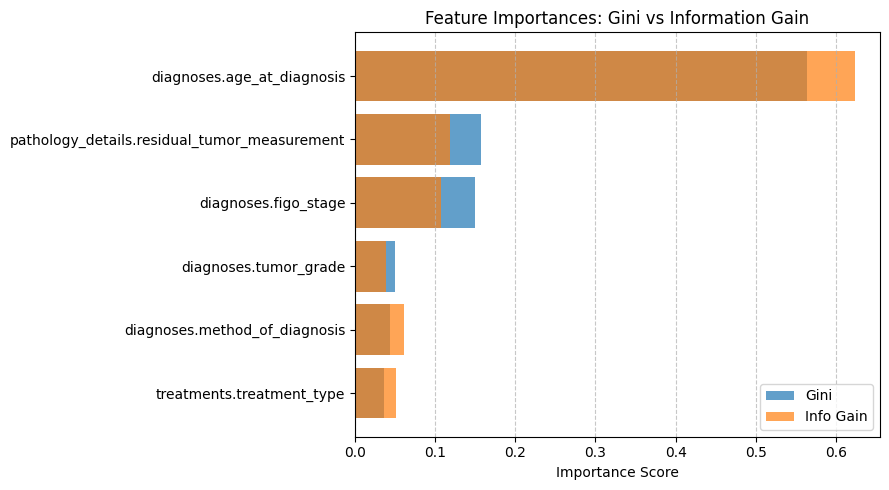

In [ ]:

from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import matplotlib.pyplot as plt

# GINI-based tree
tree_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
tree_gini.fit(X_train, y_train)
gini_importance = tree_gini.feature_importances_

# ENTROPY-based tree (Information Gain)
tree_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
tree_entropy.fit(X_train, y_train)
entropy_importance = tree_entropy.feature_importances_

# Combine and compare
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Gini Importance': gini_importance,
    'Entropy (Info Gain) Importance': entropy_importance
}).sort_values(by='Gini Importance', ascending=True)

# Plot
plt.figure(figsize=(9, 5))
plt.barh(importance_df['Feature'], importance_df['Gini Importance'], label='Gini', alpha=0.7)
plt.barh(importance_df['Feature'], importance_df['Entropy (Info Gain) Importance'], label='Info Gain', alpha=0.7)
plt.xlabel("Importance Score")
plt.title("Feature Importances: Gini vs Information Gain")
plt.legend()
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
pip install shap

XGBoost SHAP Summary:


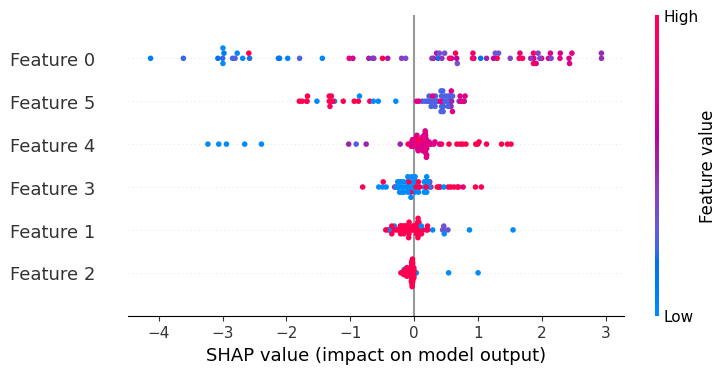

Logistic Regression SHAP Summary:


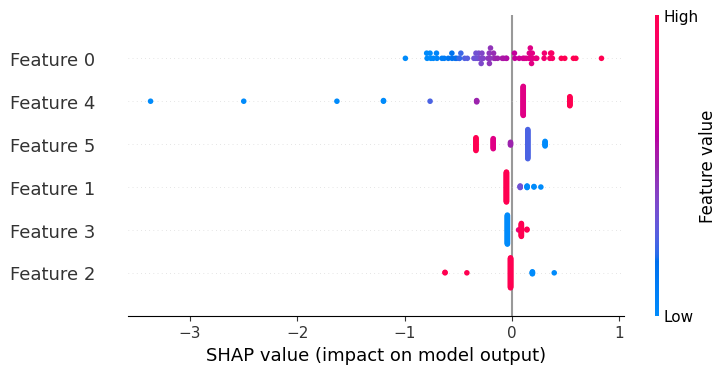

SVM SHAP Summary:


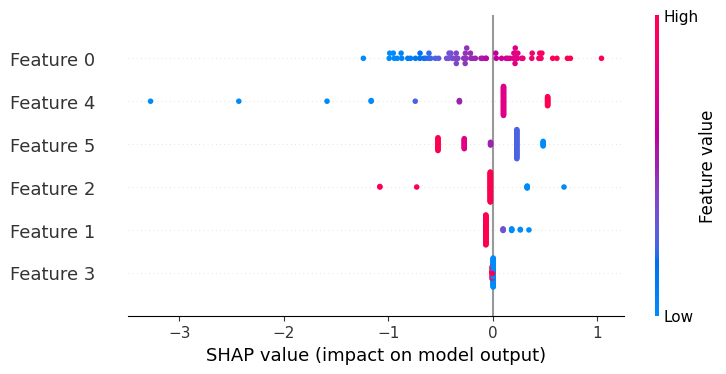

In [ ]:
import shap
import numpy as np

# Refit models for SHAP if not already done
xgb_model = xgb.XGBClassifier(eval_metric="logloss", random_state=42)
xgb_model.fit(X_train, y_train)

logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train, y_train)

svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# Use TreeExplainer for tree models, KernelExplainer for others
explainer_xgb = shap.Explainer(xgb_model, X_train)
explainer_logreg = shap.Explainer(logreg_model, X_train)
explainer_svm = shap.Explainer(svm_model, X_train)

shap_values_xgb = explainer_xgb(X_test)
shap_values_logreg = explainer_logreg(X_test)
shap_values_svm = explainer_svm(X_test)

# Plot SHAP summary plots
print("XGBoost SHAP Summary:")
shap.plots.beeswarm(shap_values_xgb, max_display=10)

print("Logistic Regression SHAP Summary:")
shap.plots.beeswarm(shap_values_logreg, max_display=10)

print("SVM SHAP Summary:")
shap.plots.beeswarm(shap_values_svm, max_display=10)

In [ ]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Initialize models again if needed
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "XGBoost": xgb.XGBClassifier(eval_metric="logloss", random_state=42),
    "SVM": SVC(kernel="linear", probability=True, random_state=42)
}

# Compare metrics
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values(by="ROC AUC", ascending=False)
print("\nModel Comparison:\n")
print(results_df)


Model Comparison:

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
3  Logistic Regression  0.557143   0.555556  0.694444  0.617284  0.669935
5                  SVM  0.542857   0.545455  0.666667  0.600000  0.640523
0        Decision Tree  0.571429   0.583333  0.583333  0.583333  0.571078
2    Gradient Boosting  0.542857   0.543478  0.694444  0.609756  0.544935
4              XGBoost  0.485714   0.500000  0.583333  0.538462  0.537582
1        Random Forest  0.514286   0.525000  0.583333  0.552632  0.527369


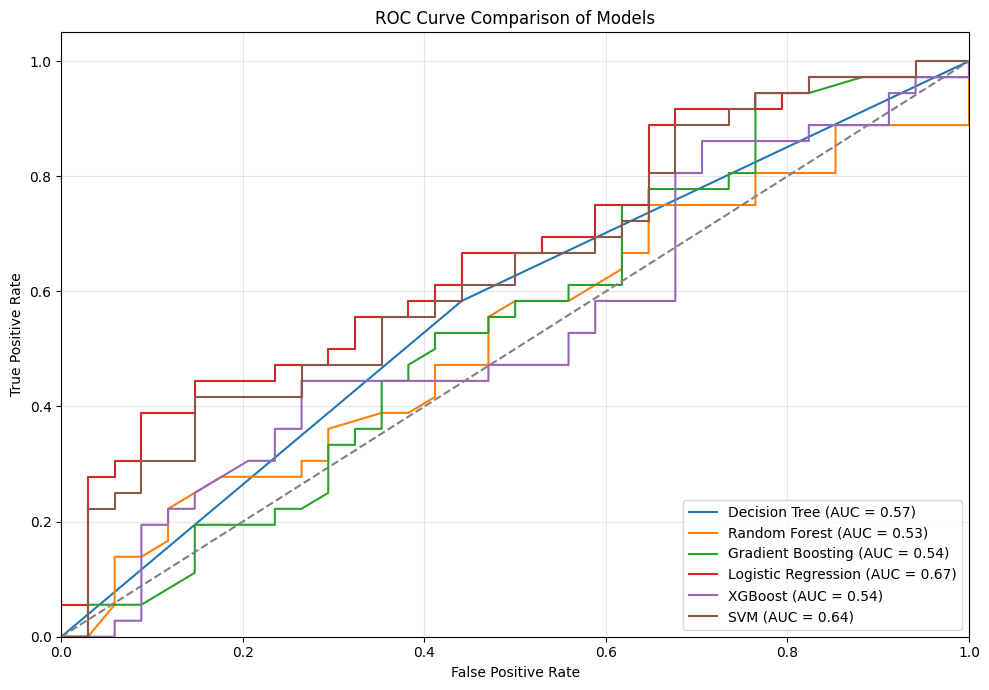

In [ ]:

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for name, model in models.items():
    model.fit(X_train, y_train)

    # Get predicted probabilities for positive class
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        # For SVM without probability=True, fallback to decision_function
        y_prob = model.decision_function(X_test)

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot each ROC curve
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot settings
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()